# Fourier Series Demonstration

In this notebook we deomnstrate the calculation procedure of fourier series; followed by its reconstruction

In [19]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt 
from scipy import integrate

For the purpose of this demonstration we use a square wave

In [20]:
T = 2
# periodicity of the signal 
t = sp.symbols("t")
x = sp.Piecewise((t - (t//T)*T, t%T<=T/4), (T/2 + (t//T)*T - t, (t%T>T/4) & (t%T<=3*T/4)), (t-T - (t//T)*T, (t%T>3*T/4) & (t%T<=T)))

## Plotting the signal 

The above signal is in symbolic form. We need to convert this into a numerical form

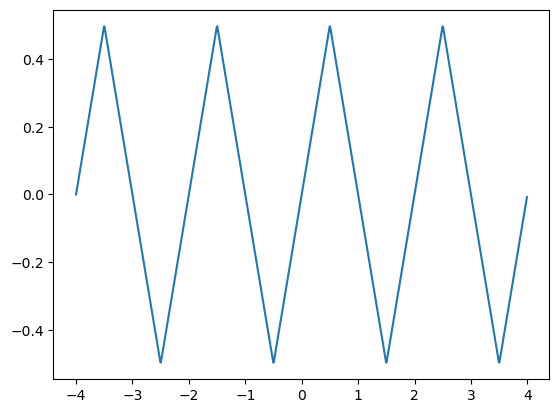

In [21]:
tvec = np.linspace(-2*T, 2*T, 1000, endpoint=False)
xnum = sp.lambdify(t, x)
plt.plot(tvec, xnum(tvec))

In [22]:
sp.integrate(x, (t, 0, T))

Integral(Piecewise((t - 2*floor(t/2), Mod(t, 2) <= 0.5), (-1.0*t + 2.0*floor(t/2) + 1.0, Mod(t, 2) <= 1.5), (t - 2*floor(t/2) - 2, Mod(t, 2) <= 2)), (t, 0, 2))

The symbolic integration does not work here ! 

Probably the use of modulo function has confused the computation here

In [23]:
sp.integrate(1, (t, 0, T/2))

1.00000000000000

Thus we jump to numerical integration at this stage. 

To perform the numerical integration we need to define a function which returns the value of the integrand. Thus, we will implement the integration in two parts namely - the real and the imaginary

In [24]:
def realintegrand(t, f, n):
    '''This function returns the real part of the integrand used in
    the Fourier series integral'''
    w0 = 2*np.pi/T
    trig = np.cos(n*w0*t)
    return f(t)*trig/T

def imagintegrand(t, f, n):
    '''This function returns the imaginary part of the integrand used in
    the Fourier series integral'''
    w0 = 2*np.pi/T
    trig = np.sin(n*w0*t)
    return f(t)*trig/T

def fourier_coefficient(f, n):
    realans, errreal = integrate.quad(realintegrand, 0, T, args=(f, n,))
    imagans, errimag = integrate.quad(imagintegrand, 0, T, args=(f, n,))
    return errreal, errimag, realans-1.0j*imagans



In [91]:
fourier2 = np.vectorize(fourier_coefficient)

N = 50
nvec = np.arange(-N, N, 1)
errR, errI, X = fourier2(xnum, nvec)

## Plotting the Fourier Coefficients

Text(0.5, 0, 'Order of the Fourier Coefficients')

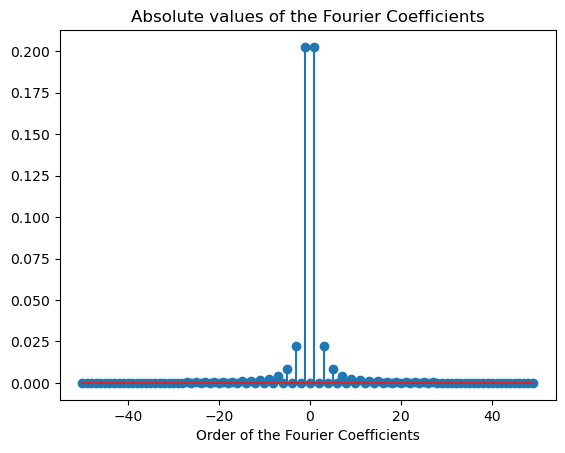

In [92]:
plt.stem(nvec, np.abs(X), use_line_collection=True)
plt.title('Absolute values of the Fourier Coefficients')
plt.xlabel('Order of the Fourier Coefficients')

Text(0.5, 0, 'Order of the Fourier Coefficients')

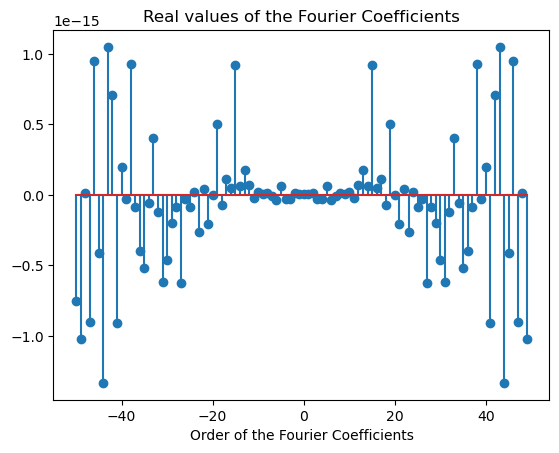

In [105]:
plt.stem(nvec, np.real(X), use_line_collection=True)
plt.title('Real values of the Fourier Coefficients')
plt.xlabel('Order of the Fourier Coefficients')

Text(0.5, 0, 'Order of the Fourier Coefficients')

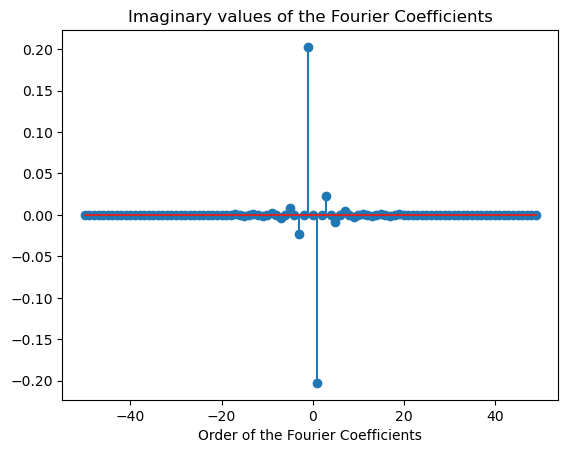

In [106]:
plt.stem(nvec, np.imag(X), use_line_collection=True)
plt.title('Imaginary values of the Fourier Coefficients')
plt.xlabel('Order of the Fourier Coefficients')

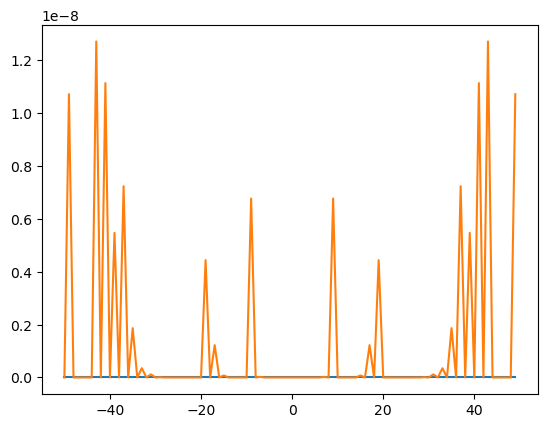

In [104]:
plt.plot(nvec, errR)
plt.plot(nvec, errI)
plt.show()

## Parseval's theorem 

Power in time domain 

In [96]:
sp.integrate(1, (t, 0, T/2))/T

0.500000000000000

In [97]:
np.sum(np.abs(X)**2)

0.08333322391700332

# Reconstruction 
Using the Fourier coefficients we will now reconstruct the time signal 

In [98]:
recon = np.zeros_like(tvec, dtype=complex)
w0 = 2*np.pi/T 
count1 = 0 
    
for count in nvec:
    # n = nvec[count1]
    argmnt = count*w0*tvec
    cexp = np.exp(1.0j*argmnt)
    recon = recon+X[count1]*cexp 
    count1 = count1+1 
    

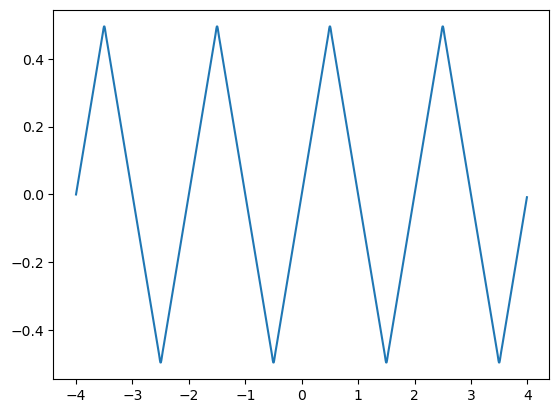

In [99]:
plt.plot(tvec, np.real(recon))

In [100]:
# %matplotlib notebook

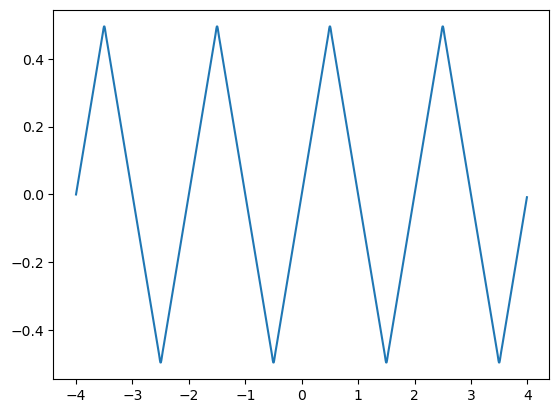

In [101]:
plt.plot(tvec, np.real(recon))